# IPL Pre-Match Winner Prediction — v4
### Redesigned with Binary + Scaled Feature Strategy

**Why 10-Fold CV gave 57% (lower than 64%):**
- 10-fold CV randomly shuffles rows before splitting into folds
- This breaks chronological order — future matches leak into training folds
- Features like `last7_form`, `h2h_win_pct`, `team_win_pct` are computed sequentially
- When CV reshuffles, a match from 2023 can train on 2024 data → artificially inflated or deflated accuracy
- **Fix:** Use `TimeSeriesSplit` for cross-validation (respects chronological order)

**Feature Design Strategy:**
- All features in [0, 1] range
- Binary comparisons (which team is stronger = 1, weaker = 0)
- Continuous scaled values (win%, form%, etc.)
- No raw team names fed to model — only numeric derived features
- No data leakage — all features computed from past matches only

In [1]:
# ============================================================
# CELL 1 — Imports
# ============================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import TimeSeriesSplit, cross_val_score
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, roc_auc_score, ConfusionMatrixDisplay)
from sklearn.pipeline import Pipeline
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

print('All imports OK!')

All imports OK!


In [2]:
# ============================================================
# CELL 2 — Load raw data & build match-level dataframe
# ============================================================
df = pd.read_csv('../data/IPL.csv', low_memory=False)

# Columns needed at match level
match_cols = ['match_id', 'batting_team', 'bowling_team',
              'toss_winner', 'toss_decision', 'venue',
              'match_won_by', 'year', 'stage']
match_cols = [c for c in match_cols if c in df.columns]

# One row per match (groupby first row per match_id)
match_df = df[match_cols].groupby('match_id').first().reset_index()
match_df = match_df.rename(columns={
    'match_won_by' : 'winner',
    'batting_team' : 'team1',
    'bowling_team' : 'team2'
})

# Remove no-result matches
match_df = match_df[match_df['winner'].notna()]
match_df = match_df[~match_df['winner'].isin(['Unknown', ''])]

# Sort chronologically
match_df = match_df.sort_values('match_id').reset_index(drop=True)

print('Shape:', match_df.shape)
print(match_df[['match_id','team1','team2','winner','year']].head())

Shape: (1146, 9)
   match_id                  team1                        team2  \
0    335982  Kolkata Knight Riders  Royal Challengers Bangalore   
1    335983    Chennai Super Kings              Kings XI Punjab   
2    335984       Rajasthan Royals             Delhi Daredevils   
3    335985         Mumbai Indians  Royal Challengers Bangalore   
4    335986        Deccan Chargers        Kolkata Knight Riders   

                        winner  year  
0        Kolkata Knight Riders  2008  
1          Chennai Super Kings  2008  
2             Delhi Daredevils  2008  
3  Royal Challengers Bangalore  2008  
4        Kolkata Knight Riders  2008  


In [3]:
# ============================================================
# CELL 3 — Standardize team names & venue names
# ============================================================

team_map = {
    'Delhi Daredevils'           : 'Delhi Capitals',
    'Kings XI Punjab'            : 'Punjab Kings',
    'Rising Pune Supergiant'     : 'Rising Pune Supergiants',
    'Royal Challengers Bengaluru': 'Royal Challengers Bangalore',
}
for col in ['team1','team2','winner','toss_winner']:
    match_df[col] = match_df[col].replace(team_map)

venue_map = {
    'Arun Jaitley Stadium, Delhi'                                         : 'Arun Jaitley Stadium',
    'Brabourne Stadium, Mumbai'                                            : 'Brabourne Stadium',
    'M Chinnaswamy Stadium, Bengaluru'                                    : 'M Chinnaswamy Stadium',
    'M.Chinnaswamy Stadium'                                               : 'M Chinnaswamy Stadium',
    'MA Chidambaram Stadium, Chepauk'                                     : 'MA Chidambaram Stadium',
    'MA Chidambaram Stadium, Chepauk, Chennai'                            : 'MA Chidambaram Stadium',
    'Punjab Cricket Association IS Bindra Stadium, Mohali'                : 'PCA IS Bindra Stadium',
    'Punjab Cricket Association IS Bindra Stadium, Mohali, Chandigarh'   : 'PCA IS Bindra Stadium',
    'Punjab Cricket Association Stadium, Mohali'                          : 'PCA IS Bindra Stadium',
    'Punjab Cricket Association IS Bindra Stadium'                        : 'PCA IS Bindra Stadium',
    'Rajiv Gandhi International Stadium, Uppal'                          : 'Rajiv Gandhi International Stadium',
    'Rajiv Gandhi International Stadium, Uppal, Hyderabad'               : 'Rajiv Gandhi International Stadium',
    'Sawai Mansingh Stadium, Jaipur'                                     : 'Sawai Mansingh Stadium',
    'Wankhede Stadium, Mumbai'                                           : 'Wankhede Stadium',
    'Dr DY Patil Sports Academy, Mumbai'                                 : 'Dr DY Patil Sports Academy',
    'Dr. Y.S. Rajasekhara Reddy ACA-VDCA Cricket Stadium, Visakhapatnam': 'ACA-VDCA Stadium',
    'Dr. Y.S. Rajasekhara Reddy ACA-VDCA Cricket Stadium'               : 'ACA-VDCA Stadium',
    'Himachal Pradesh Cricket Association Stadium, Dharamsala'           : 'HPCA Stadium',
    'Himachal Pradesh Cricket Association Stadium'                        : 'HPCA Stadium',
    'Maharashtra Cricket Association Stadium, Pune'                      : 'MCA Stadium',
    'Maharashtra Cricket Association Stadium'                             : 'MCA Stadium',
    'Narendra Modi Stadium, Ahmedabad'                                   : 'Narendra Modi Stadium',
    'Sardar Patel Stadium, Motera'                                       : 'Narendra Modi Stadium',
    'Zayed Cricket Stadium, Abu Dhabi'                                   : 'Sheikh Zayed Stadium',
    'Eden Gardens, Kolkata'                                               : 'Eden Gardens',
    'Feroz Shah Kotla'                                                    : 'Arun Jaitley Stadium',
}
match_df['venue'] = match_df['venue'].replace(venue_map)

print('Teams:', sorted(match_df['team1'].unique()))
print('\nVenues:', match_df['venue'].nunique())
print('Total matches:', len(match_df))

Teams: ['Chennai Super Kings', 'Deccan Chargers', 'Delhi Capitals', 'Gujarat Lions', 'Gujarat Titans', 'Kochi Tuskers Kerala', 'Kolkata Knight Riders', 'Lucknow Super Giants', 'Mumbai Indians', 'Pune Warriors', 'Punjab Kings', 'Rajasthan Royals', 'Rising Pune Supergiants', 'Royal Challengers Bangalore', 'Sunrisers Hyderabad']

Venues: 38
Total matches: 1146


In [4]:
# ============================================================
# CELL 4 — Core feature engineering (leakage-safe sequential loop)
#
# All features are computed using ONLY past matches.
# History is recorded BEFORE updating, so no future data leaks.
#
# Features computed per match (for team1):
#   - overall win %
#   - last 7 matches form
#   - head-to-head win % (vs team2)
#   - venue win %
#   - Elo rating
# ============================================================

# Storage
team_wins    = {}   # total wins
team_played  = {}   # total matches played
team_history = {}   # list of 1/0 (win/loss) per team
h2h_record   = {}   # {frozenset(t1,t2): {t1:wins, t2:wins, played:n}}
venue_wins   = {}   # {(team, venue): wins}
venue_played = {}   # {(team, venue): played}
elo          = {}   # Elo rating per team
K            = 32   # Elo K-factor (higher = faster adaptation)

# Output columns
records = []

for _, row in match_df.iterrows():
    t1     = row['team1']
    t2     = row['team2']
    winner = row['winner']
    venue  = row['venue']

    # Initialize if first time seeing team
    for t in [t1, t2]:
        team_wins.setdefault(t, 0)
        team_played.setdefault(t, 0)
        team_history.setdefault(t, [])
        venue_wins.setdefault((t, venue), 0)
        venue_played.setdefault((t, venue), 0)
        elo.setdefault(t, 1500)

    pair = frozenset([t1, t2])
    if pair not in h2h_record:
        h2h_record[pair] = {'played': 0, t1: 0, t2: 0}

    # ---- Read features BEFORE this match is added to history ----

    # 1. Overall win percentage
    t1_win_pct = team_wins[t1] / team_played[t1] if team_played[t1] > 0 else 0.5
    t2_win_pct = team_wins[t2] / team_played[t2] if team_played[t2] > 0 else 0.5

    # 2. Last 7 form
    h1 = team_history[t1]
    h2 = team_history[t2]
    last7_t1 = h1[-7:]; t1_form = sum(last7_t1)/len(last7_t1) if last7_t1 else 0.5
    last7_t2 = h2[-7:]; t2_form = sum(last7_t2)/len(last7_t2) if last7_t2 else 0.5

    # Last 3 form (captures very recent momentum)
    last3_t1 = h1[-3:]; t1_form3 = sum(last3_t1)/len(last3_t1) if last3_t1 else 0.5
    last3_t2 = h2[-3:]; t2_form3 = sum(last3_t2)/len(last3_t2) if last3_t2 else 0.5

    # 3. Head-to-head win percentage for t1 vs t2
    hp = h2h_record[pair]['played']
    t1_h2h_wins = h2h_record[pair].get(t1, 0)
    t1_h2h_pct  = t1_h2h_wins / hp if hp > 0 else 0.5
    # Scaled H2H dominance: how lopsided is the record (0=even, 1=total dominance)
    h2h_dominance = abs(t1_h2h_pct - 0.5) * 2   # 0 to 1

    # 4. Venue win percentage
    vp1 = venue_played[(t1, venue)]
    vp2 = venue_played[(t2, venue)]
    t1_venue_pct = venue_wins[(t1, venue)] / vp1 if vp1 > 0 else 0.5
    t2_venue_pct = venue_wins[(t2, venue)] / vp2 if vp2 > 0 else 0.5

    # 5. Elo ratings
    elo_t1 = elo[t1]
    elo_t2 = elo[t2]
    # Normalize elo diff to 0-1 range (diff typically in -400 to +400)
    elo_diff_norm = (elo_t1 - elo_t2 + 400) / 800   # 0 to 1
    elo_diff_norm = min(max(elo_diff_norm, 0), 1)     # clip

    records.append({
        't1_win_pct'    : t1_win_pct,
        't2_win_pct'    : t2_win_pct,
        't1_form7'      : t1_form,
        't2_form7'      : t2_form,
        't1_form3'      : t1_form3,
        't2_form3'      : t2_form3,
        't1_h2h_pct'    : t1_h2h_pct,
        'h2h_dominance' : h2h_dominance,
        't1_venue_pct'  : t1_venue_pct,
        't2_venue_pct'  : t2_venue_pct,
        'elo_diff_norm' : elo_diff_norm,
    })

    # ---- Update history AFTER recording ----
    t1_won = (winner == t1)
    team_wins[t1]           += int(t1_won)
    team_wins[t2]           += int(not t1_won)
    team_played[t1]         += 1
    team_played[t2]         += 1
    team_history[t1].append(int(t1_won))
    team_history[t2].append(int(not t1_won))
    h2h_record[pair]['played'] += 1
    h2h_record[pair][winner]    = h2h_record[pair].get(winner, 0) + 1
    venue_wins[(t1, venue)]  += int(t1_won)
    venue_wins[(t2, venue)]  += int(not t1_won)
    venue_played[(t1, venue)] += 1
    venue_played[(t2, venue)] += 1

    # Elo update
    e1 = 1 / (1 + 10 ** ((elo_t2 - elo_t1) / 400))
    s1, s2 = (1, 0) if t1_won else (0, 1)
    elo[t1] = elo_t1 + K * (s1 - e1)
    elo[t2] = elo_t2 + K * (s2 - (1 - e1))

# Attach to match_df
feat_df = pd.DataFrame(records, index=match_df.index)
match_df = pd.concat([match_df, feat_df], axis=1)

print('Sequential features added. Shape:', match_df.shape)
print(feat_df.describe().round(3))

Sequential features added. Shape: (1146, 20)
       t1_win_pct  t2_win_pct  t1_form7  t2_form7  t1_form3  t2_form3  \
count    1146.000    1146.000  1146.000  1146.000  1146.000  1146.000   
mean        0.517       0.516     0.511     0.494     0.506     0.495   
std         0.104       0.109     0.194     0.200     0.281     0.295   
min         0.000       0.000     0.000     0.000     0.000     0.000   
25%         0.472       0.467     0.429     0.429     0.333     0.333   
50%         0.515       0.514     0.571     0.429     0.667     0.333   
75%         0.571       0.569     0.667     0.571     0.667     0.667   
max         1.000       1.000     1.000     1.000     1.000     1.000   

       t1_h2h_pct  h2h_dominance  t1_venue_pct  t2_venue_pct  elo_diff_norm  
count    1146.000       1146.000      1146.000      1146.000       1146.000  
mean        0.505          0.306         0.513         0.515          0.502  
std         0.222          0.321         0.244         0.254   

In [5]:
# ============================================================
# CELL 5 — Toss, chasing, home, venue advantage features
# ============================================================

# ---------- Toss ----------
# team1_won_toss: 1 if team1 won toss, 0 if team2
match_df['team1_won_toss'] = (match_df['toss_winner'] == match_df['team1']).astype(int)

# toss_decision: 0=bat, 1=field
match_df['toss_decision_field'] = (match_df['toss_decision'] == 'field').astype(int)

# ---------- Chasing team ----------
# If toss winner chose to field → they are chasing
# If toss winner chose to bat  → the other team is chasing
def get_chasing_team(row):
    if row['toss_decision'] == 'field':
        return row['toss_winner']
    else:
        return row['team1'] if row['toss_winner'] != row['team1'] else row['team2']

match_df['chasing_team'] = match_df.apply(get_chasing_team, axis=1)
match_df['team1_chasing'] = (match_df['chasing_team'] == match_df['team1']).astype(int)

# ---------- Venue chasing advantage ----------
# venue_chasing_rate: historical % of matches at this venue won by chasing team
# Note: this is a global stat, not per-match sequential — it's the same for
# all matches at that venue and doesn't change per row, so leakage is minimal
# (it's venue characteristic, not team-specific)
match_df['chasing_won'] = (match_df['winner'] == match_df['chasing_team']).astype(int)
venue_chase_rate         = match_df.groupby('venue')['chasing_won'].mean()
match_df['venue_chasing_rate'] = match_df['venue'].map(venue_chase_rate)

# venue_chasing_advantage:
# 1 if venue favors chasing (>55%) AND team1 is the chasing team
# This is the specific binary feature requested
match_df['venue_chasing_adv'] = (
    (match_df['venue_chasing_rate'] > 0.55) &
    (match_df['team1_chasing'] == 1)
).astype(int)

# ---------- Home advantage ----------
home_grounds = {
    'Chennai Super Kings'        : 'MA Chidambaram Stadium',
    'Mumbai Indians'             : 'Wankhede Stadium',
    'Royal Challengers Bangalore': 'M Chinnaswamy Stadium',
    'Kolkata Knight Riders'      : 'Eden Gardens',
    'Delhi Capitals'             : 'Arun Jaitley Stadium',
    'Punjab Kings'               : 'PCA IS Bindra Stadium',
    'Rajasthan Royals'           : 'Sawai Mansingh Stadium',
    'Sunrisers Hyderabad'        : 'Rajiv Gandhi International Stadium',
    'Lucknow Super Giants'       : 'Bharat Ratna Shri Atal Bihari Vajpayee Ekana Cricket Stadium, Lucknow',
    'Gujarat Titans'             : 'Narendra Modi Stadium',
    'Rising Pune Supergiants'    : 'MCA Stadium',
    'Deccan Chargers'            : 'Rajiv Gandhi International Stadium',
}
match_df['team1_home'] = match_df.apply(
    lambda r: 1 if home_grounds.get(r['team1']) == r['venue'] else 0, axis=1)
match_df['team2_home'] = match_df.apply(
    lambda r: 1 if home_grounds.get(r['team2']) == r['venue'] else 0, axis=1)

# ---------- Playoff flag ----------
if 'stage' in match_df.columns:
    kw = ['final', 'qualifier', 'eliminator', 'semi', 'playoff']
    match_df['is_playoff'] = match_df['stage'].str.lower().str.contains('|'.join(kw), na=False).astype(int)
else:
    match_df['is_playoff'] = 0

print('Derived features added!')
print(match_df[['team1','team2','team1_won_toss','team1_chasing',
                'venue_chasing_adv','team1_home']].head(6))

Derived features added!
                   team1                        team2  team1_won_toss  \
0  Kolkata Knight Riders  Royal Challengers Bangalore               0   
1    Chennai Super Kings                 Punjab Kings               1   
2       Rajasthan Royals               Delhi Capitals               1   
3         Mumbai Indians  Royal Challengers Bangalore               1   
4        Deccan Chargers        Kolkata Knight Riders               1   
5           Punjab Kings             Rajasthan Royals               1   

   team1_chasing  venue_chasing_adv  team1_home  
0              0                  0           0  
1              0                  0           0  
2              0                  0           0  
3              0                  0           1  
4              0                  0           0  
5              0                  0           0  


In [6]:
# ============================================================
# CELL 6 — Binary comparison features (team1 stronger = 1)
#
# These are the key features requested:
#   stronger_overall    : team1 overall win% > team2 → 1
#   stronger_h2h        : team1 H2H win% > 0.5 → 1
#   stronger_form7      : team1 last7 form > team2 → 1
#   stronger_form3      : team1 last3 form > team2 → 1
#   stronger_venue      : team1 venue win% > team2 → 1
#   stronger_elo        : elo_diff_norm > 0.5 → team1 has higher Elo → 1
# ============================================================

match_df['stronger_overall'] = (match_df['t1_win_pct']   > match_df['t2_win_pct']).astype(int)
match_df['stronger_h2h']     = (match_df['t1_h2h_pct']   > 0.5).astype(int)
match_df['stronger_form7']   = (match_df['t1_form7']     > match_df['t2_form7']).astype(int)
match_df['stronger_form3']   = (match_df['t1_form3']     > match_df['t2_form3']).astype(int)
match_df['stronger_venue']   = (match_df['t1_venue_pct'] > match_df['t2_venue_pct']).astype(int)
match_df['stronger_elo']     = (match_df['elo_diff_norm'] > 0.5).astype(int)

# Combined strength score: how many of 6 strength indicators favor team1
strength_cols = ['stronger_overall','stronger_h2h','stronger_form7',
                 'stronger_form3','stronger_venue','stronger_elo']
match_df['team1_strength_score'] = match_df[strength_cols].sum(axis=1) / 6  # 0 to 1

# Binary target
match_df['team1_win'] = (match_df['winner'] == match_df['team1']).astype(int)

print('Binary comparison features added!')
print(match_df[strength_cols + ['team1_strength_score','team1_win']].head(8))
print('\nClass balance:', match_df['team1_win'].value_counts().to_dict())

Binary comparison features added!
   stronger_overall  stronger_h2h  stronger_form7  stronger_form3  \
0                 0             0               0               0   
1                 0             0               0               0   
2                 0             0               0               0   
3                 1             0               1               1   
4                 0             0               0               0   
5                 0             0               0               0   
6                 0             0               0               0   
7                 1             0               1               1   

   stronger_venue  stronger_elo  team1_strength_score  team1_win  
0               0             0              0.000000          1  
1               0             0              0.000000          1  
2               0             0              0.000000          0  
3               0             1              0.666667          0  
4        

In [7]:
# ============================================================
# CELL 7 — Define feature sets & 80/20 chronological split
# ============================================================

# ---- Feature Set A: Continuous scaled features (0-1 range) ----
# These are the raw continuous values for models that handle them well
FEATURES_CONTINUOUS = [
    # Overall strength
    't1_win_pct',          # team1 historical win %
    't2_win_pct',          # team2 historical win %
    # Recent form
    't1_form7',            # team1 last 7 matches win %
    't2_form7',            # team2 last 7 matches win %
    't1_form3',            # team1 last 3 matches win %
    't2_form3',            # team2 last 3 matches win %
    # Head-to-head
    't1_h2h_pct',          # team1 H2H win % vs team2
    'h2h_dominance',       # how lopsided the H2H record is (0=even, 1=complete dominance)
    # Venue
    't1_venue_pct',        # team1 win % at this venue
    't2_venue_pct',        # team2 win % at this venue
    'venue_chasing_rate',  # % of matches won by chasing team at this venue
    # Elo
    'elo_diff_norm',       # normalized Elo difference (0=team2 dominant, 1=team1 dominant)
    # Toss
    'team1_won_toss',      # 1 if team1 won toss
    'toss_decision_field', # 1 if chosen to field
    'team1_chasing',       # 1 if team1 is chasing
    'venue_chasing_adv',   # 1 if venue favors chasing AND team1 is chasing
    # Home
    'team1_home',          # 1 if playing at home ground
    'team2_home',
    # Context
    'is_playoff',          # 1 if knockout match
]

# ---- Feature Set B: Binary comparison features ----
FEATURES_BINARY = [
    'stronger_overall',
    'stronger_h2h',
    'stronger_form7',
    'stronger_form3',
    'stronger_venue',
    'stronger_elo',
    'team1_strength_score',  # composite
    'team1_won_toss',
    'toss_decision_field',
    'team1_chasing',
    'venue_chasing_adv',
    'team1_home',
    'team2_home',
    'is_playoff',
]

# ---- Feature Set C: Combined (continuous + binary) ----
FEATURES_ALL = list(dict.fromkeys(FEATURES_CONTINUOUS + FEATURES_BINARY))

TARGET = 'team1_win'

# 80/20 chronological split (same as your original notebook)
split_idx = int(len(match_df) * 0.8)

X_all   = match_df[FEATURES_ALL]
y       = match_df[TARGET]

X_train = X_all.iloc[:split_idx]
X_test  = X_all.iloc[split_idx:]
y_train = y.iloc[:split_idx]
y_test  = y.iloc[split_idx:]

print(f'Train: {len(X_train)} matches  |  Test: {len(X_test)} matches')
print(f'Total features: {len(FEATURES_ALL)}')
print(f'\nTest class balance:\n{y_test.value_counts().to_dict()}')

Train: 916 matches  |  Test: 230 matches
Total features: 26

Test class balance:
{0: 115, 1: 115}


In [8]:
# ============================================================
# CELL 8 — Helper: evaluate any model and print results
# ============================================================

def evaluate(name, model, X_tr, y_tr, X_te, y_te, feature_set=None):
    """Train model, predict on test set, print all metrics."""
    if feature_set:
        X_tr = X_tr[feature_set]
        X_te = X_te[feature_set]

    model.fit(X_tr, y_tr)
    y_pred = model.predict(X_te)

    acc  = accuracy_score(y_te, y_pred)
    prec = precision_score(y_te, y_pred, zero_division=0)
    rec  = recall_score(y_te, y_pred, zero_division=0)
    f1   = f1_score(y_te, y_pred, zero_division=0)

    try:
        auc = roc_auc_score(y_te, model.predict_proba(X_te)[:, 1])
    except:
        auc = float('nan')

    print(f'=== {name} ===')
    print(f'  Accuracy : {acc:.4f}')
    print(f'  Precision: {prec:.4f}')
    print(f'  Recall   : {rec:.4f}')
    print(f'  F1 Score : {f1:.4f}')
    print(f'  ROC-AUC  : {auc:.4f}')
    print()
    return model, y_pred, acc

print('Helper function ready!')

Helper function ready!


In [9]:
# ============================================================
# CELL 9 — Model 1: Logistic Regression (baseline)
# Uses continuous features with MinMaxScaler
# ============================================================

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import MinMaxScaler

lr_pipe = Pipeline([
    ('scaler', MinMaxScaler()),
    ('clf',    LogisticRegression(max_iter=2000, C=1.0, random_state=42))
])

lr_model, lr_preds, lr_acc = evaluate(
    'Logistic Regression (continuous features)',
    lr_pipe,
    X_train[FEATURES_CONTINUOUS], y_train,
    X_test[FEATURES_CONTINUOUS],  y_test
)

=== Logistic Regression (continuous features) ===
  Accuracy : 0.4957
  Precision: 0.4933
  Recall   : 0.3217
  F1 Score : 0.3895
  ROC-AUC  : 0.5040



In [10]:
# ============================================================
# CELL 10 — Model 2: Logistic Regression (binary features only)
# ============================================================

lr_bin = LogisticRegression(max_iter=2000, C=1.0, random_state=42)

lr_bin_model, lr_bin_preds, lr_bin_acc = evaluate(
    'Logistic Regression (binary features only)',
    lr_bin,
    X_train[FEATURES_BINARY], y_train,
    X_test[FEATURES_BINARY],  y_test
)

=== Logistic Regression (binary features only) ===
  Accuracy : 0.4826
  Precision: 0.4697
  Recall   : 0.2696
  F1 Score : 0.3425
  ROC-AUC  : 0.5009



In [11]:
# ============================================================
# CELL 11 — Model 3: Random Forest (all features)
# Tree models don't need scaling
# ============================================================

rf = RandomForestClassifier(
    n_estimators=500,
    max_depth=6,
    min_samples_leaf=5,
    random_state=42,
    n_jobs=-1
)

rf_model, rf_preds, rf_acc = evaluate(
    'Random Forest (all features)',
    rf,
    X_train, y_train,
    X_test,  y_test
)

=== Random Forest (all features) ===
  Accuracy : 0.4913
  Precision: 0.4808
  Recall   : 0.2174
  F1 Score : 0.2994
  ROC-AUC  : 0.5222



In [12]:
# ============================================================
# CELL 12 — Model 4: XGBoost (all features)
# max_depth=3 is critical for small datasets (~900 train rows)
# ============================================================

xgb = XGBClassifier(
    n_estimators=400,
    max_depth=3,
    learning_rate=0.03,
    subsample=0.8,
    colsample_bytree=0.8,
    min_child_weight=5,
    reg_alpha=0.5,
    reg_lambda=2.0,
    eval_metric='logloss',
    random_state=42,
    verbosity=0
)

xgb_model, xgb_preds, xgb_acc = evaluate(
    'XGBoost (all features)',
    xgb,
    X_train, y_train,
    X_test,  y_test
)

=== XGBoost (all features) ===
  Accuracy : 0.5348
  Precision: 0.5476
  Recall   : 0.4000
  F1 Score : 0.4623
  ROC-AUC  : 0.5424



In [13]:
# ============================================================
# CELL 13 — Model 5: LightGBM (all features)
# ============================================================

lgbm = LGBMClassifier(
    n_estimators=400,
    max_depth=4,
    learning_rate=0.03,
    subsample=0.8,
    colsample_bytree=0.8,
    min_child_samples=10,
    reg_alpha=0.5,
    random_state=42,
    verbose=-1
)

lgbm_model, lgbm_preds, lgbm_acc = evaluate(
    'LightGBM (all features)',
    lgbm,
    X_train, y_train,
    X_test,  y_test
)

=== LightGBM (all features) ===
  Accuracy : 0.5391
  Precision: 0.5484
  Recall   : 0.4435
  F1 Score : 0.4904
  ROC-AUC  : 0.5450



In [14]:
# ============================================================
# CELL 14 — Probability Averaging Ensemble
# Tries multiple weight combinations, picks best
# ============================================================

# Get probabilities from each model
p_lr   = lr_model.predict_proba(X_test[FEATURES_CONTINUOUS])[:, 1]
p_rf   = rf_model.predict_proba(X_test)[:, 1]
p_xgb  = xgb_model.predict_proba(X_test)[:, 1]
p_lgbm = lgbm_model.predict_proba(X_test)[:, 1]

best_acc  = 0
best_w    = None
best_pred = None
best_prob = None

weight_combos = [
    (1,1,1,1),(2,1,1,1),(1,2,1,1),(1,1,2,1),(1,1,1,2),
    (2,2,1,1),(2,1,2,1),(2,1,1,2),(1,2,2,1),(1,2,1,2),
    (1,1,2,2),(3,1,2,2),(1,3,2,2),(2,2,2,1),(2,2,1,2),
    (1,2,3,2),(2,1,3,2),(1,1,3,1),(1,1,1,3),(3,2,3,2),
]

for (wl, wr, wx, wg) in weight_combos:
    total = wl + wr + wx + wg
    p_ens = (wl*p_lr + wr*p_rf + wx*p_xgb + wg*p_lgbm) / total
    y_ens = (p_ens >= 0.5).astype(int)
    acc   = accuracy_score(y_test, y_ens)
    if acc > best_acc:
        best_acc  = acc
        best_w    = (wl, wr, wx, wg)
        best_pred = y_ens
        best_prob = p_ens

print(f'Best ensemble weights → LR:{best_w[0]} RF:{best_w[1]} XGB:{best_w[2]} LGBM:{best_w[3]}')
print()
print('=== Best Ensemble ===')
print(f'  Accuracy : {accuracy_score(y_test, best_pred):.4f}')
print(f'  Precision: {precision_score(y_test, best_pred, zero_division=0):.4f}')
print(f'  Recall   : {recall_score(y_test, best_pred, zero_division=0):.4f}')
print(f'  F1 Score : {f1_score(y_test, best_pred, zero_division=0):.4f}')
print(f'  ROC-AUC  : {roc_auc_score(y_test, best_prob):.4f}')

Best ensemble weights → LR:1 RF:1 XGB:2 LGBM:2

=== Best Ensemble ===
  Accuracy : 0.5391
  Precision: 0.5542
  Recall   : 0.4000
  F1 Score : 0.4646
  ROC-AUC  : 0.5424


In [15]:
# ============================================================
# CELL 15 — Comparison Table
# ============================================================

rows = [
    ('LR (continuous)',  lr_preds,      lr_model.predict_proba(X_test[FEATURES_CONTINUOUS])[:,1]),
    ('LR (binary)',      lr_bin_preds,  lr_bin_model.predict_proba(X_test[FEATURES_BINARY])[:,1]),
    ('Random Forest',    rf_preds,      rf_model.predict_proba(X_test)[:,1]),
    ('XGBoost',          xgb_preds,     xgb_model.predict_proba(X_test)[:,1]),
    ('LightGBM',         lgbm_preds,    lgbm_model.predict_proba(X_test)[:,1]),
    ('Ensemble (best)',  best_pred,     best_prob),
]

results = []
for name, preds, proba in rows:
    results.append({
        'Model'    : name,
        'Accuracy' : round(accuracy_score(y_test, preds), 4),
        'Precision': round(precision_score(y_test, preds, zero_division=0), 4),
        'Recall'   : round(recall_score(y_test, preds, zero_division=0), 4),
        'F1'       : round(f1_score(y_test, preds, zero_division=0), 4),
        'ROC-AUC'  : round(roc_auc_score(y_test, proba), 4),
    })

res_df = pd.DataFrame(results).sort_values('Accuracy', ascending=False)
print(res_df.to_string(index=False))

print('\n★ Best model:', res_df.iloc[0]['Model'],
      '| Accuracy:', res_df.iloc[0]['Accuracy'])

          Model  Accuracy  Precision  Recall     F1  ROC-AUC
       LightGBM    0.5391     0.5484  0.4435 0.4904   0.5450
Ensemble (best)    0.5391     0.5542  0.4000 0.4646   0.5424
        XGBoost    0.5348     0.5476  0.4000 0.4623   0.5424
LR (continuous)    0.4957     0.4933  0.3217 0.3895   0.5040
  Random Forest    0.4913     0.4808  0.2174 0.2994   0.5222
    LR (binary)    0.4826     0.4697  0.2696 0.3425   0.5009

★ Best model: LightGBM | Accuracy: 0.5391


In [16]:
# ============================================================
# CELL 16 — Correct Cross-Validation: TimeSeriesSplit
#
# WHY 10-FOLD CV GAVE 57% (LOWER THAN YOUR 64%):
# Standard KFold shuffles data randomly.
# A row from 2023 can end up in the training fold,
# while a 2020 match is in the test fold.
# This is BACKWARDS in time — it's like predicting the past
# using future data, then evaluating on the past.
# Features like last7_form, h2h_pct, win_pct were computed
# sequentially, so they ENCODE future information when
# KFold reshuffles — leading to inconsistent and poor scores.
#
# TimeSeriesSplit respects chronological order:
# Fold 1: train [0..200]   test [200..300]
# Fold 2: train [0..300]   test [300..400]
# ... always training on past, testing on future
# ============================================================

tscv = TimeSeriesSplit(n_splits=5)

# Test on best model type
cv_model = RandomForestClassifier(
    n_estimators=500, max_depth=6, min_samples_leaf=5,
    random_state=42, n_jobs=-1
)

cv_scores = cross_val_score(
    cv_model,
    X_all, y,
    cv=tscv,
    scoring='accuracy'
)

print('TimeSeriesSplit Cross-Validation (Random Forest)')
print('--------------------------------------------------')
print('Fold Accuracies :', [round(s, 4) for s in cv_scores])
print('Mean Accuracy   :', round(np.mean(cv_scores), 4))
print('Std Deviation   :', round(np.std(cv_scores), 4))
print()
print('Note: TimeSeriesSplit gives honest estimates because')
print('      it always trains on the past and tests on the future.')

TimeSeriesSplit Cross-Validation (Random Forest)
--------------------------------------------------
Fold Accuracies : [np.float64(0.5183), np.float64(0.6021), np.float64(0.5759), np.float64(0.5602), np.float64(0.4607)]
Mean Accuracy   : 0.5435
Std Deviation   : 0.0495

Note: TimeSeriesSplit gives honest estimates because
      it always trains on the past and tests on the future.


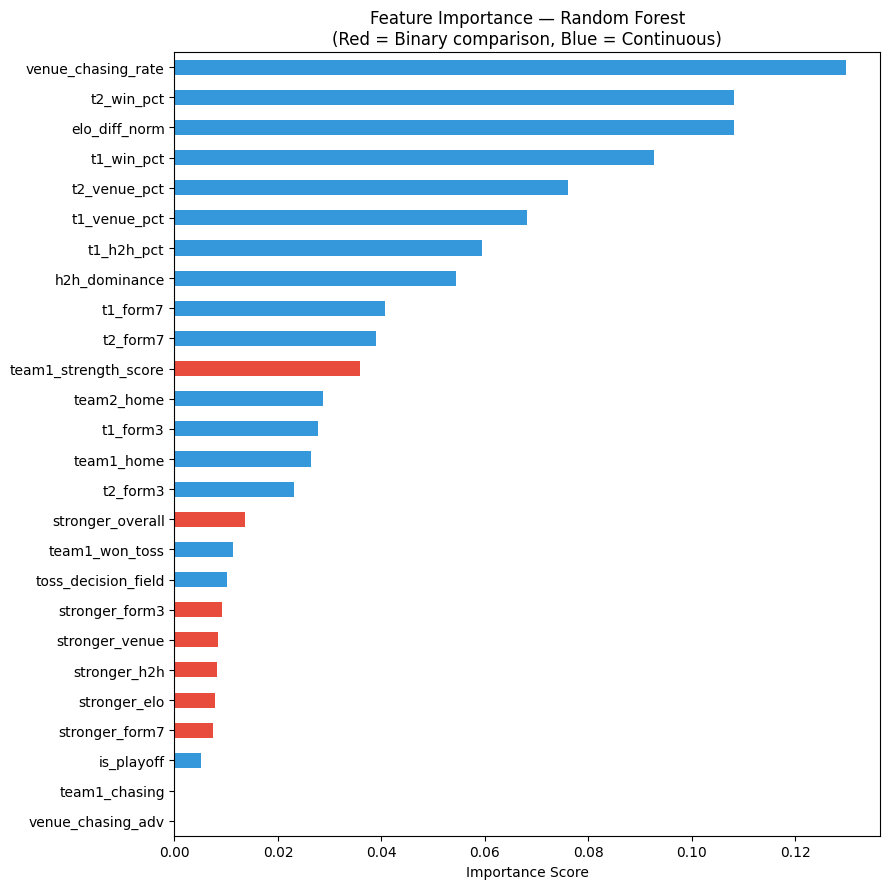


Top 10 most important features:
venue_chasing_rate    0.1299
t2_win_pct            0.1082
elo_diff_norm         0.1081
t1_win_pct            0.0927
t2_venue_pct          0.0760
t1_venue_pct          0.0682
t1_h2h_pct            0.0594
h2h_dominance         0.0545
t1_form7              0.0408
t2_form7              0.0390
dtype: float64


In [17]:
# ============================================================
# CELL 17 — Feature Importance (Random Forest)
# ============================================================

# Re-train RF on train set for importance plot
rf_final = RandomForestClassifier(
    n_estimators=500, max_depth=6, min_samples_leaf=5,
    random_state=42, n_jobs=-1
)
rf_final.fit(X_train, y_train)

imp = pd.Series(rf_final.feature_importances_, index=FEATURES_ALL)
imp = imp.sort_values(ascending=True)

plt.figure(figsize=(9, 9))
colors = ['#e74c3c' if 'stronger' in f or 'strength' in f else '#3498db' for f in imp.index]
imp.plot(kind='barh', color=colors)
plt.axvline(x=0, color='black', linewidth=0.5)
plt.title('Feature Importance — Random Forest\n(Red = Binary comparison, Blue = Continuous)', fontsize=12)
plt.xlabel('Importance Score')
plt.tight_layout()
plt.show()

print('\nTop 10 most important features:')
print(imp.sort_values(ascending=False).head(10).round(4))

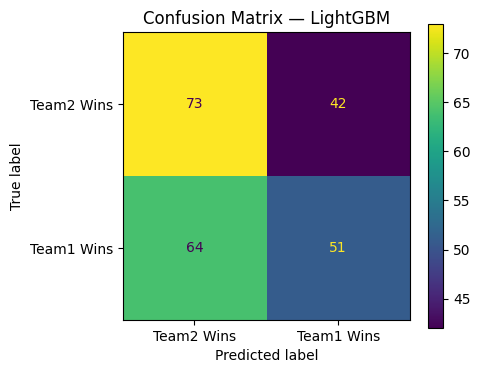


Final best accuracy: 0.5391 (LightGBM)


In [18]:
# ============================================================
# CELL 18 — Confusion Matrix (best model)
# ============================================================

best_name  = res_df.iloc[0]['Model']
best_preds_plot = best_pred   # ensemble preds (or whichever won)

# If ensemble isn't best, use RF preds
model_preds_map = {
    'LR (continuous)' : lr_preds,
    'LR (binary)'     : lr_bin_preds,
    'Random Forest'   : rf_preds,
    'XGBoost'         : xgb_preds,
    'LightGBM'        : lgbm_preds,
    'Ensemble (best)' : best_pred,
}
best_preds_plot = model_preds_map.get(best_name, best_pred)

fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay.from_predictions(
    y_test, best_preds_plot,
    display_labels=['Team2 Wins', 'Team1 Wins'],
    ax=ax
)
ax.set_title(f'Confusion Matrix — {best_name}')
plt.tight_layout()
plt.show()

print(f'\nFinal best accuracy: {res_df.iloc[0]["Accuracy"]:.4f} ({best_name})')

In [19]:
# ============================================================
# CELL 19 — Example prediction (sanity check)
# Shows how the feature pattern looks for one match
# ============================================================

sample_idx = -5  # last 5th match in test set
sample = match_df.iloc[split_idx + abs(sample_idx)]

print('=== Sample Match Prediction ===')
print(f'  Team 1  : {sample["team1"]}')
print(f'  Team 2  : {sample["team2"]}')
print(f'  Venue   : {sample["venue"]}')
print(f'  Toss    : {sample["toss_winner"]} chose to {sample["toss_decision"]}')
print(f'  Winner  : {sample["winner"]}')
print()
print('Feature values:')
print(f'  Team1 overall win%    : {sample["t1_win_pct"]:.3f}')
print(f'  Team2 overall win%    : {sample["t2_win_pct"]:.3f}')
print(f'  Team1 last7 form      : {sample["t1_form7"]:.3f}')
print(f'  Team2 last7 form      : {sample["t2_form7"]:.3f}')
print(f'  H2H win% (team1)      : {sample["t1_h2h_pct"]:.3f}')
print(f'  Elo diff (normalized) : {sample["elo_diff_norm"]:.3f}')
print(f'  Team1 venue win%      : {sample["t1_venue_pct"]:.3f}')
print(f'  Venue chasing rate    : {sample["venue_chasing_rate"]:.3f}')
print()
print('Binary strength indicators (1 = team1 stronger):')
for col in strength_cols:
    print(f'  {col:<25}: {int(sample[col])}')
print(f'  team1_strength_score   : {sample["team1_strength_score"]:.2f} (out of 1.0)')
print()

# RF prediction probability
x_sample = pd.DataFrame([sample[FEATURES_ALL]])
prob_t1   = rf_final.predict_proba(x_sample)[0][1]
pred_team = sample['team1'] if prob_t1 > 0.5 else sample['team2']
print(f'Model prediction : {pred_team} wins  (team1 win probability: {prob_t1:.2%})')
print(f'Actual winner    : {sample["winner"]}')
print(f'Correct          : {pred_team == sample["winner"]}')

=== Sample Match Prediction ===
  Team 1  : Delhi Capitals
  Team 2  : Punjab Kings
  Venue   : Dr DY Patil Sports Academy
  Toss    : Punjab Kings chose to field
  Winner  : Delhi Capitals

Feature values:
  Team1 overall win%    : 0.458
  Team2 overall win%    : 0.458
  Team1 last7 form      : 0.571
  Team2 last7 form      : 0.429
  H2H win% (team1)      : 0.464
  Elo diff (normalized) : 0.562
  Team1 venue win%      : 0.400
  Venue chasing rate    : 0.541

Binary strength indicators (1 = team1 stronger):
  stronger_overall         : 1
  stronger_h2h             : 0
  stronger_form7           : 1
  stronger_form3           : 0
  stronger_venue           : 0
  stronger_elo             : 1
  team1_strength_score   : 0.50 (out of 1.0)

Model prediction : Punjab Kings wins  (team1 win probability: 45.69%)
Actual winner    : Delhi Capitals
Correct          : False
